In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions

# Load pre-trained MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Load and preprocess an image
img = image.load_img('your_image.jpg', target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict the image class
predictions = model.predict(img_array)
decoded_predictions = decode_predictions(predictions, top=3)[0]

for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{label}: {score * 100:.2f}%")

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 397s 902ms/step - accuracy: 0.4909 - loss: 1.2376 - val_accuracy: 0.6801 - val_loss: 0.8511
Epoch 2/10
  1/438 ━━━━━━━━━━━━━━━━━━━━ 2:19 319ms/step - accuracy: 0.6562 - loss: 0.9170

F:\MSc. in Data Science\Semester 2\Data Analytics and Algorithms\Projects\DecisionTrees\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6562 - loss: 0.9170 - val_accuracy: 0.6925 - val_loss: 0.8487
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 153s 349ms/step - accuracy: 0.7143 - loss: 0.7454 - val_accuracy: 0.7809 - val_loss: 0.5974
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8438 - loss: 0.4712 - val_accuracy: 0.7886 - val_loss: 0.5756
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 155s 354ms/step - accuracy: 0.8003 - loss: 0.5384 - val_accuracy: 0.8001 - val_loss: 0.5631
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9688 - loss: 0.2347 - val_accuracy: 0.8122 - val_loss: 0.5257
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 165s 376ms/step - accuracy: 0.8407 - loss: 0.4480 - val_accuracy: 0.8340 - val_loss: 0.4782
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7812 - loss: 0.6012 - val_accuracy: 0.8327 - val_loss: 0.4821
Epoch 9/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 151s 345ms/step - accuracy: 0.8626 - loss: 0.3796 - val_acc

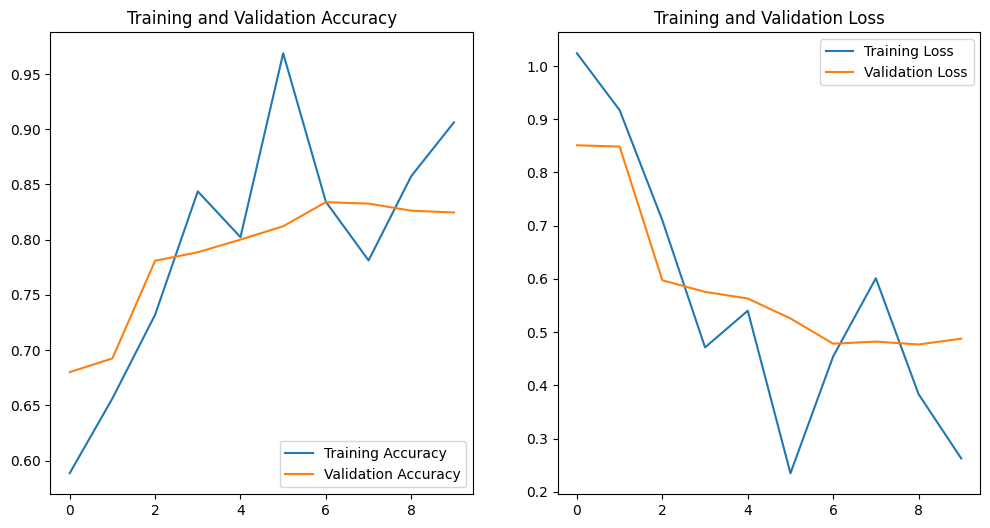

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Directories for training, testing, and prediction
train_dir = 'archive/seg_train/seg_train'
test_dir = 'archive/seg_test/seg_test'
pred_dir = 'archive/seg_pred/seg_pred'

# Image dimensions
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# ImageDataGenerator to load and preprocess images from directories
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Defining the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(6, activation='softmax')  # 6 output classes: buildings, forest, glacier, etc.
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,  # You can change the number of epochs
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print(f"\nTest accuracy: {test_acc*100:.2f}%")

# Plotting training & validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Save the model
model.save('cnn_model.h5')


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the saved model
model = tf.keras.models.load_model('cnn_model.h5')

# Function to classify a single image
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Reshape for model prediction
    img_array = img_array / 255.0  # Normalize the image

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)
    class_labels = list(train_generator.class_indices.keys())
    
    print(f"Predicted Class: {class_labels[predicted_class[0]]}")
    print(f"Confidence: {prediction[0][predicted_class[0]] * 100:.2f}%")

# Classify images from the prediction folder
for img_name in os.listdir(pred_dir):
    img_path = os.path.join(pred_dir, img_name)
    print(f"\nClassifying image: {img_name}")
    classify_image(img_path)



Classifying image: 10004.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Class: street
Confidence: 83.78%

Classifying image: 10005.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: sea
Confidence: 68.71%

Classifying image: 10012.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Class: street
Confidence: 61.93%

Classifying image: 10013.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Class: mountain
Confidence: 83.06%

Classifying image: 10017.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: glacier
Confidence: 68.05%

Classifying image: 10021.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: forest
Confidence: 99.97%

Classifying image: 1003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: sea
Confidence: 98.15%

Classifying image: 10034.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: glacier
Confidence: 92.23%

Classifying image: 10038.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: sea
Confidence: 99.77%

Class